# Análise exploratória de volume de combustível

O notebook descreve as séries nacionais de volume de diesel e gasolina. O foco é a venda mensal da ANP. Quando a série existe, o grupo compara com a venda trimestral da Petrobras.


In [ ]:
import sys
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8')

cwd = Path.cwd().resolve()
if (cwd / 'src').is_dir() and (cwd / 'data').is_dir():
    project_root = cwd
elif (cwd.parent / 'src').is_dir() and (cwd.parent / 'data').is_dir():
    project_root = cwd.parent
else:
    raise FileNotFoundError(
        'Could not locate proj_IV root (expected src/ and data/). '
        'Open notebooks from proj_IV/ or proj_IV/notebooks/.'
    )

sys.path.insert(0, str(project_root / 'src'))

from db_access import read_engine, resolve_database_url

ENGINE = read_engine(project_root)
DATABASE_URL = resolve_database_url(project_root)
DATABASE_URL

In [2]:
anp_query = '''
SELECT product, month, volume_m3
FROM anp_fuel_sales
ORDER BY month, product
'''

pbr_query = '''
SELECT product, year, quarter, sales_mbpd
FROM pbr_quarterly_sales
ORDER BY year, quarter, product
'''

ppi_range_query = '''
SELECT MIN(report_date) AS min_date, MAX(report_date) AS max_date
FROM ppi_daily
'''

anp = pd.read_sql_query(anp_query, ENGINE)
pbr = pd.read_sql_query(pbr_query, ENGINE)
ppi_range = pd.read_sql_query(ppi_range_query, ENGINE)

anp['month'] = pd.to_datetime(anp['month'], errors='coerce')
if not pbr.empty:
    pbr['year'] = pbr['year'].astype(int)
    pbr['quarter'] = pbr['quarter'].astype(int)
    pbr['quarter_start'] = pd.PeriodIndex.from_fields(year=pbr['year'], quarter=pbr['quarter'], freq='Q').end_time.normalize()

product_label = {
    'diesel': 'Diesel',
    'gasolina_c': 'Gasoline C',
}
anp['product_label'] = anp['product'].map(product_label).fillna(anp['product'])
anp['month_plot'] = anp['month'] + pd.offsets.MonthEnd(0)
if not pbr.empty:
    pbr['product_label'] = pbr['product'].map(product_label).fillna(pbr['product'])

anp.head()

,product,month,volume_m3,product_label,month_plot
0,diesel,2022-01-01,4636961.246,Diesel,2022-01-31
1,gasolina_c,2022-01-01,3271353.292,Gasoline C,2022-01-31
2,diesel,2022-02-01,4929325.533,Diesel,2022-02-28
3,gasolina_c,2022-02-01,3321083.560,Gasoline C,2022-02-28
4,diesel,2022-03-01,5461778.952,Diesel,2022-03-31


In [3]:
print(f'ANP rows: {len(anp):,}')
print(f'PBR rows: {len(pbr):,}')
print(f"ANP date range: {anp['month'].min().date()} to {anp['month'].max().date()}")

ppi_min = pd.to_datetime(ppi_range.loc[0, 'min_date'], errors='coerce')
ppi_max = pd.to_datetime(ppi_range.loc[0, 'max_date'], errors='coerce')
print(f'PPI coverage: {ppi_min.date()} to {ppi_max.date()}')

anp = anp[anp['month'] >= ppi_min].copy()
if not pbr.empty:
    pbr = pbr[pbr['quarter_start'] >= ppi_min].copy()

if not pbr.empty:
    print(f"PBR quarter range: {pbr['year'].min()}Q{pbr['quarter'].min()} to {pbr['year'].max()}Q{pbr['quarter'].max()}")

summary = pd.DataFrame({
    'rows': [len(anp), len(pbr)],
    'products': [anp['product'].nunique(), pbr['product'].nunique() if not pbr.empty else 0],
    'min_period': [anp['month'].min(), pbr['quarter_start'].min() if not pbr.empty else pd.NaT],
    'max_period': [anp['month'].max(), pbr['quarter_start'].max() if not pbr.empty else pd.NaT],
}, index=['anp_fuel_sales', 'pbr_quarterly_sales'])
summary

ANP rows: 104
PBR rows: 34
ANP date range: 2022-01-01 to 2026-04-01
PPI coverage: 2022-01-05 to 2026-06-24
PBR quarter range: 2022Q1 to 2026Q4


,rows,products,min_period,max_period
anp_fuel_sales,102,2,2022-02-01,2026-04-01
pbr_quarterly_sales,34,2,2022-03-31,2026-03-31


In [4]:
if pbr.empty:
    print('PBR quarterly table is empty.')
else:
    pbr_view = pbr[['year', 'quarter', 'product_label', 'sales_mbpd']].sort_values(['year', 'quarter', 'product_label'])
    print(f"PBR quarterly rows: {len(pbr_view):,}")
    display(pbr_view.tail(16))


PBR quarterly rows: 34


,year,quarter,product_label,sales_mbpd
18,2024,2,Diesel,717.0
19,2024,2,Gasoline C,392.0
20,2024,3,Diesel,760.0
21,2024,3,Gasoline C,396.0
22,2024,4,Diesel,731.0
23,2024,4,Gasoline C,432.0
24,2025,1,Diesel,734.0
25,2025,1,Gasoline C,398.0
26,2025,2,Diesel,721.0
27,2025,2,Gasoline C,404.0


In [5]:
if pbr.empty:
    print('Latest quarter snapshot unavailable (no PBR data).')
else:
    latest_year = int(pbr['year'].max())
    latest_quarter = int(pbr[pbr['year'] == latest_year]['quarter'].max())
    latest = pbr[(pbr['year'] == latest_year) & (pbr['quarter'] == latest_quarter)].copy()
    latest['product_label'] = latest['product'].map(product_label).fillna(latest['product'])
    snapshot = latest[['product_label', 'sales_mbpd']].sort_values('product_label').reset_index(drop=True)
    total_row = pd.DataFrame([{'product_label': 'Total', 'sales_mbpd': snapshot['sales_mbpd'].sum()}])
    snapshot = pd.concat([snapshot, total_row], ignore_index=True)
    print(f"Latest PBR quarter: {latest_year}Q{latest_quarter}")
    display(snapshot)


Latest PBR quarter: 2026Q1


,product_label,sales_mbpd
0,Diesel,738.0
1,Gasoline C,413.0
2,Total,1151.0


In [6]:
def count_missing_months(series: pd.Series) -> int:
    if series.empty:
        return 0
    expected = pd.date_range(series.min(), series.max(), freq='MS')
    observed = pd.DatetimeIndex(series.dropna().unique()).sort_values()
    return len(expected.difference(observed))

quality_rows = []
for product, group in anp.groupby('product'):
    quality_rows.append({
        'source': 'ANP',
        'product': product,
        'rows': len(group),
        'null_volume': int(group['volume_m3'].isna().sum()),
        'non_positive_volume': int((group['volume_m3'] <= 0).sum()),
        'duplicates_key': int(group.duplicated(subset=['product', 'month']).sum()),
        'missing_months': count_missing_months(group['month']),
    })

if not pbr.empty:
    for product, group in pbr.groupby('product'):
        quality_rows.append({
            'source': 'PBR',
            'product': product,
            'rows': len(group),
            'null_volume': int(group['sales_mbpd'].isna().sum()),
            'non_positive_volume': int((group['sales_mbpd'] <= 0).sum()),
            'duplicates_key': int(group.duplicated(subset=['product', 'year', 'quarter']).sum()),
            'missing_months': np.nan,
        })

pd.DataFrame(quality_rows)

,source,product,rows,null_volume,non_positive_volume,duplicates_key,missing_months
0,ANP,diesel,51,0,0,0,0.0
1,ANP,gasolina_c,51,0,0,0,0.0
2,PBR,diesel,17,0,0,0,NaN
3,PBR,gasolina_c,17,0,0,0,NaN


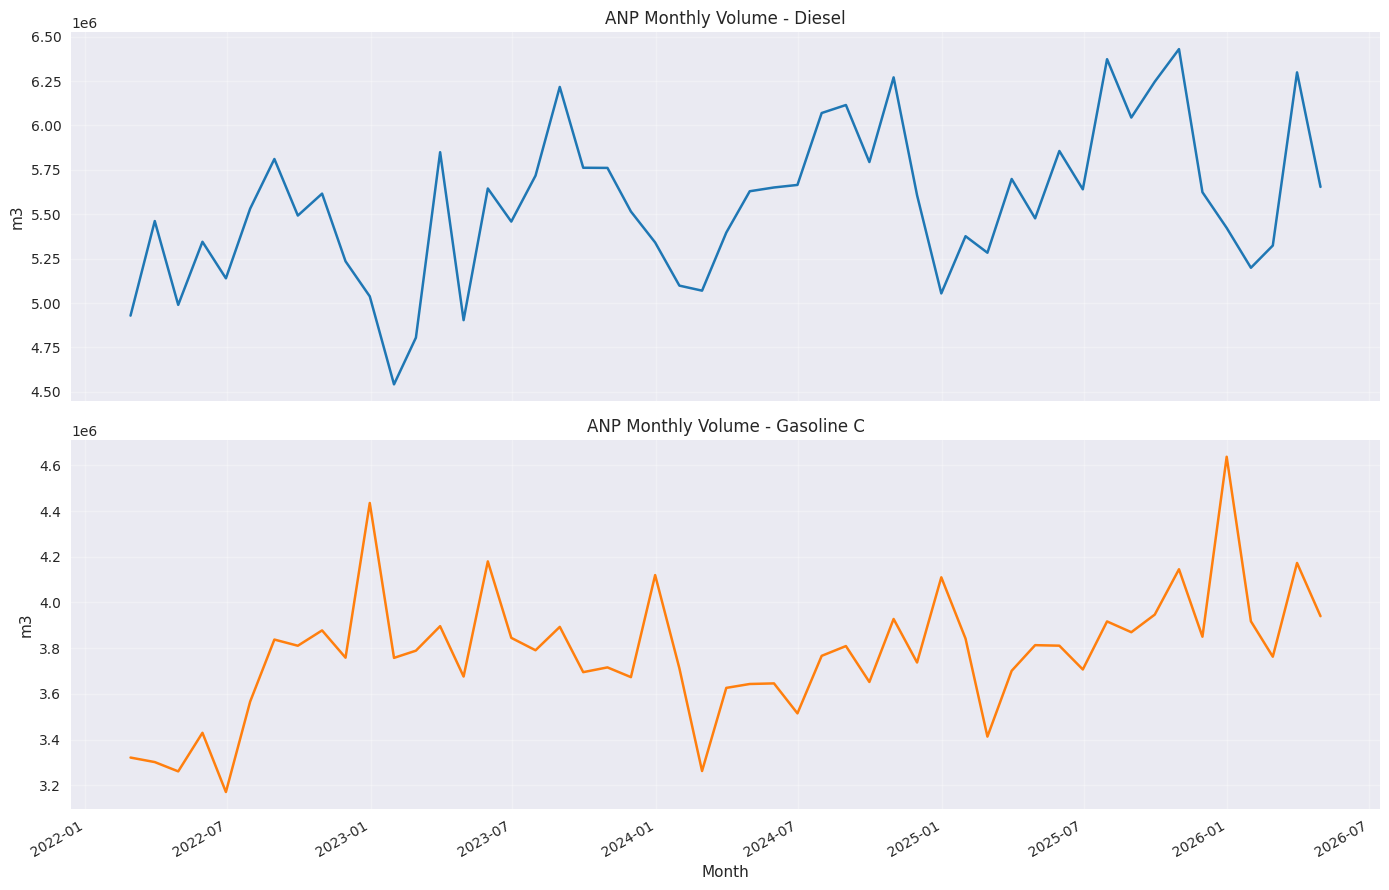

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
plot_order = ['diesel', 'gasolina_c']
colors = {'diesel': '#1f77b4', 'gasolina_c': '#ff7f0e'}

for ax, product in zip(axes, plot_order):
    g = anp[anp['product'] == product].sort_values('month')
    ax.plot(g['month_plot'], g['volume_m3'], color=colors[product], linewidth=1.8)
    ax.set_title(f"ANP Monthly Volume - {product_label.get(product, product)}")
    ax.set_ylabel('m3')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Month')
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

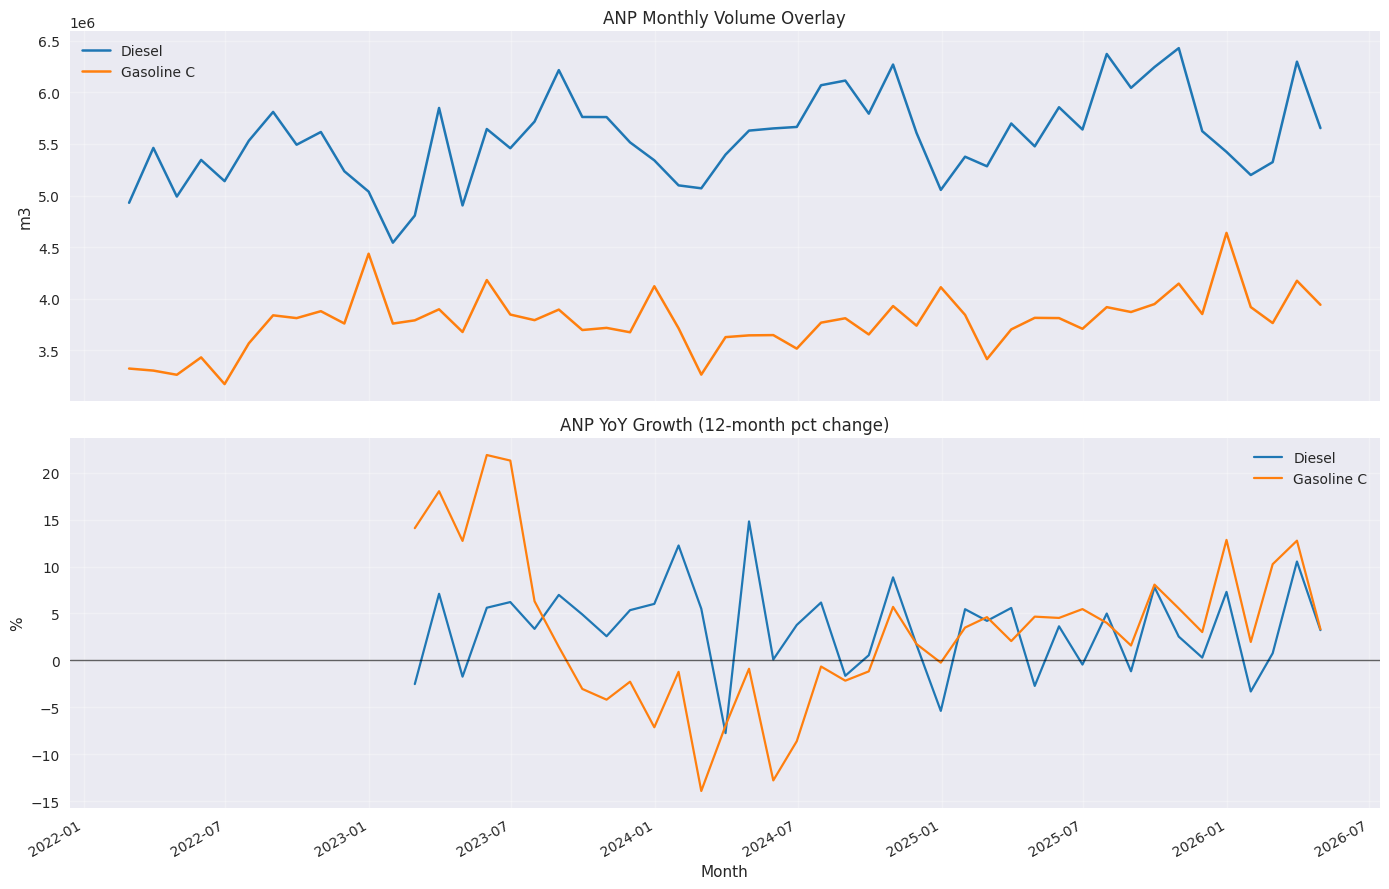

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for product in plot_order:
    g = anp[anp['product'] == product].sort_values('month').copy()
    axes[0].plot(g['month_plot'], g['volume_m3'], label=product_label.get(product, product), linewidth=1.8, color=colors[product])

    g['yoy_pct'] = g['volume_m3'].pct_change(12) * 100.0
    axes[1].plot(g['month_plot'], g['yoy_pct'], label=product_label.get(product, product), linewidth=1.6, color=colors[product])

axes[0].set_title('ANP Monthly Volume Overlay')
axes[0].set_ylabel('m3')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('ANP YoY Growth (12-month pct change)')
axes[1].axhline(0.0, color='black', linewidth=1.0, alpha=0.6)
axes[1].set_ylabel('%')
axes[1].set_xlabel('Month')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

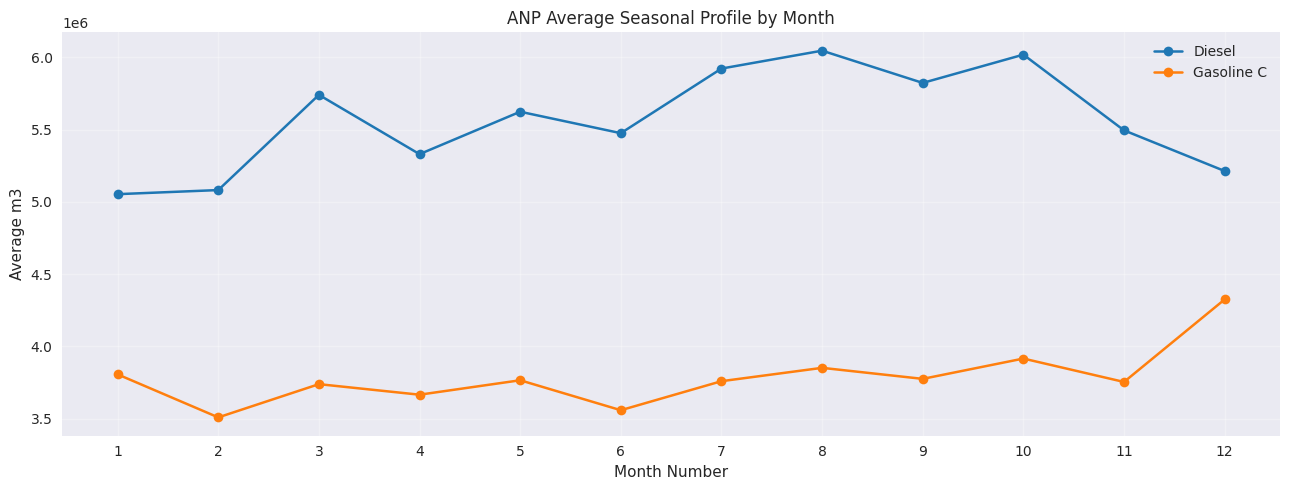

In [9]:
seasonality = anp.copy()
seasonality['month_num'] = seasonality['month'].dt.month
seasonality = seasonality.groupby(['product', 'month_num'], as_index=False)['volume_m3'].mean()

fig, ax = plt.subplots(figsize=(13, 5))
for product in plot_order:
    g = seasonality[seasonality['product'] == product]
    ax.plot(g['month_num'], g['volume_m3'], marker='o', linewidth=1.8, color=colors[product], label=product_label.get(product, product))

ax.set_title('ANP Average Seasonal Profile by Month')
ax.set_xlabel('Month Number')
ax.set_ylabel('Average m3')
ax.set_xticks(range(1, 13))
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

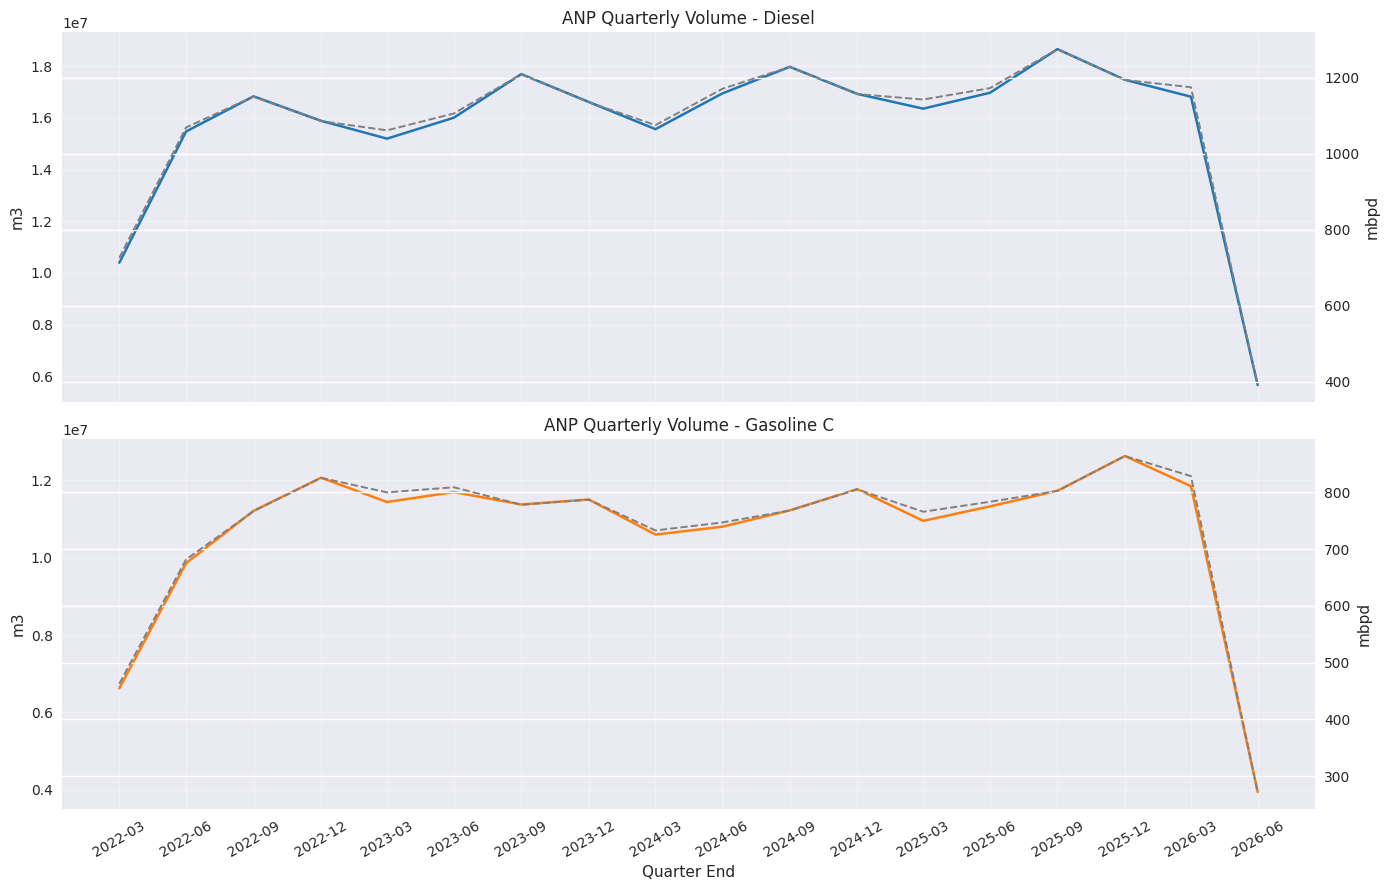

,product,quarter_label,volume_m3,volume_mbpd
0,diesel,2022-03,1.039110e+07,726.200810
1,diesel,2022-06,1.547433e+07,1069.566652
2,diesel,2022-09,1.683535e+07,1150.991125
3,diesel,2022-12,1.588919e+07,1086.304494
4,diesel,2023-03,1.519704e+07,1062.072181
5,diesel,2023-06,1.600772e+07,1106.433985
6,diesel,2023-09,1.769591e+07,1209.824832
7,diesel,2023-12,1.661774e+07,1136.113246


In [10]:
anp_q = anp.copy()
anp_q['quarter'] = anp_q['month'].dt.to_period('Q')
anp_q = anp_q.groupby(['product', 'quarter'], as_index=False)['volume_m3'].sum()
anp_q['quarter_start'] = anp_q['quarter'].dt.end_time.dt.normalize()
anp_q['days_in_quarter'] = anp_q['quarter'].dt.end_time.dt.dayofyear - anp_q['quarter'].dt.start_time.dt.dayofyear + 1
anp_q['volume_mbpd'] = anp_q['volume_m3'] * 6.28981 / anp_q['days_in_quarter'] / 1000.0
anp_q['quarter_label'] = anp_q['quarter_start'].dt.strftime('%Y-%m')

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for ax, product in zip(axes, plot_order):
    g = anp_q[anp_q['product'] == product].sort_values('quarter_start')
    ax.plot(g['quarter_start'], g['volume_m3'], linewidth=1.8, color=colors[product], label='m3 total')
    ax2 = ax.twinx()
    ax2.plot(g['quarter_start'], g['volume_mbpd'], linewidth=1.4, linestyle='--', color='gray', label='mbpd')
    ax.set_title(f"ANP Quarterly Volume - {product_label.get(product, product)}")
    ax.set_ylabel('m3')
    ax2.set_ylabel('mbpd')
    ax.grid(True, alpha=0.3)

q_ticks = sorted(pd.to_datetime(anp_q['quarter_start']).unique())
axes[-1].set_xticks(q_ticks)
axes[-1].set_xticklabels([pd.Timestamp(x).strftime('%Y-%m') for x in q_ticks], rotation=30)
axes[-1].set_xlabel('Quarter End')
plt.tight_layout()
plt.show()

anp_q[['product', 'quarter_label', 'volume_m3', 'volume_mbpd']].head(8)

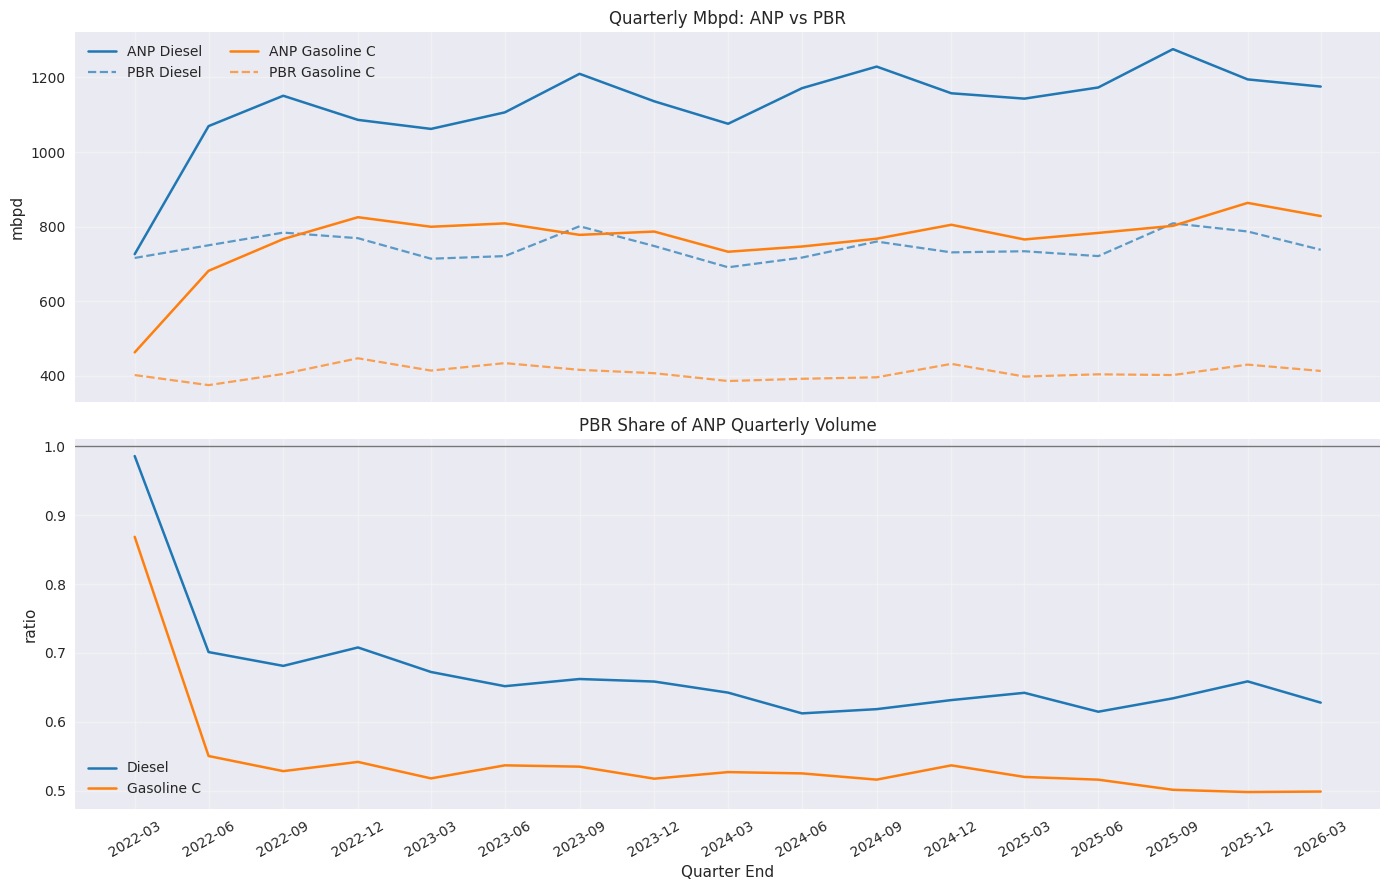

In [11]:
if pbr.empty:
    print('PBR quarterly table is empty. Run the PBR ingestion pipeline to enable ANP vs PBR comparison charts.')
else:
    merged = anp_q[['product', 'quarter_start', 'volume_mbpd']].merge(
        pbr[['product', 'quarter_start', 'sales_mbpd']],
        on=['product', 'quarter_start'],
        how='inner',
    )
    merged['quarter_label'] = merged['quarter_start'].dt.strftime('%Y-%m')
    merged['pbr_share_of_anp'] = merged['sales_mbpd'] / merged['volume_mbpd']

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
    for product in plot_order:
        g = merged[merged['product'] == product].sort_values('quarter_start')
        axes[0].plot(g['quarter_start'], g['volume_mbpd'], linewidth=1.8, color=colors[product], label=f"ANP {product_label.get(product, product)}")
        axes[0].plot(g['quarter_start'], g['sales_mbpd'], linewidth=1.6, linestyle='--', color=colors[product], alpha=0.7, label=f"PBR {product_label.get(product, product)}")
        axes[1].plot(g['quarter_start'], g['pbr_share_of_anp'], linewidth=1.8, color=colors[product], label=product_label.get(product, product))

    q_ticks = sorted(pd.to_datetime(merged['quarter_start']).unique())
    axes[-1].set_xticks(q_ticks)
    axes[-1].set_xticklabels([pd.Timestamp(x).strftime('%Y-%m') for x in q_ticks], rotation=30)

    axes[0].set_title('Quarterly Mbpd: ANP vs PBR')
    axes[0].set_ylabel('mbpd')
    axes[0].legend(loc='best', ncol=2)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title('PBR Share of ANP Quarterly Volume')
    axes[1].set_ylabel('ratio')
    axes[1].set_xlabel('Quarter End')
    axes[1].axhline(1.0, color='black', linewidth=1.0, alpha=0.5)
    axes[1].legend(loc='best')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    merged.tail(8)

In [12]:
if pbr.empty:
    print('Quarterly share table unavailable (no PBR data).')
else:
    merged = anp_q[['product', 'quarter_start', 'volume_mbpd']].merge(
        pbr[['product', 'quarter_start', 'sales_mbpd']],
        on=['product', 'quarter_start'],
        how='inner',
    )

    by_product = merged.copy()
    by_product['pbr_share_of_anp'] = by_product['sales_mbpd'] / by_product['volume_mbpd']
    by_product['product_label'] = by_product['product'].map(product_label).fillna(by_product['product'])
    by_product['quarter_label'] = by_product['quarter_start'].dt.strftime('%Y-%m')
    by_product = by_product[['quarter_label', 'quarter_start', 'product_label', 'volume_mbpd', 'sales_mbpd', 'pbr_share_of_anp']]

    totals = merged.groupby('quarter_start', as_index=False)[['volume_mbpd', 'sales_mbpd']].sum()
    totals['pbr_share_of_anp'] = totals['sales_mbpd'] / totals['volume_mbpd']
    totals['product_label'] = 'Total'
    totals['quarter_label'] = totals['quarter_start'].dt.strftime('%Y-%m')
    totals = totals[['quarter_label', 'quarter_start', 'product_label', 'volume_mbpd', 'sales_mbpd', 'pbr_share_of_anp']]

    share_table = pd.concat([by_product, totals], ignore_index=True)
    share_table = share_table.sort_values(['quarter_start', 'product_label']).reset_index(drop=True)

    print('Quarterly ANP vs PBR share table (latest 12 rows):')
    display(share_table[['quarter_label', 'product_label', 'volume_mbpd', 'sales_mbpd', 'pbr_share_of_anp']].tail(12))


Quarterly ANP vs PBR share table (latest 12 rows):


,quarter_label,product_label,volume_mbpd,sales_mbpd,pbr_share_of_anp
39,2025-06,Diesel,1173.202987,721.0,0.614557
40,2025-06,Gasoline C,783.144645,404.0,0.515869
41,2025-06,Total,1956.347632,1125.0,0.575051
42,2025-09,Diesel,1275.997634,809.0,0.634014
43,2025-09,Gasoline C,802.176101,402.0,0.501137
44,2025-09,Total,2078.173735,1211.0,0.582723
45,2025-12,Diesel,1194.874001,787.0,0.658647
46,2025-12,Gasoline C,863.675197,430.0,0.497872
47,2025-12,Total,2058.549198,1217.0,0.591193
48,2026-03,Diesel,1175.600734,738.0,0.627764


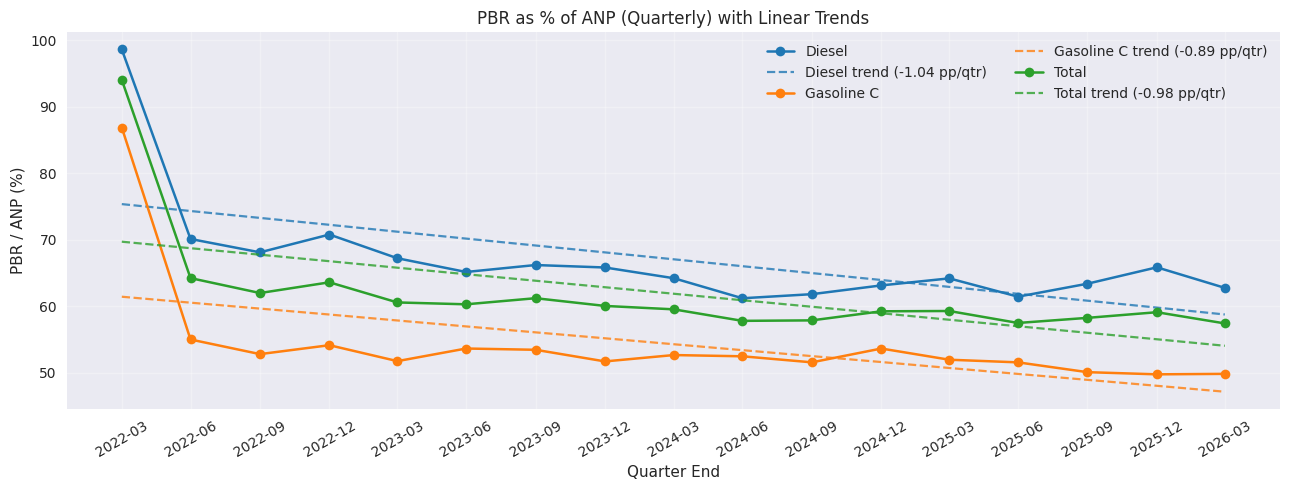

,series,slope_pp_per_quarter,intercept,r2,n_obs
0,Diesel,-1.036,75.361,0.371,17
1,Gasoline C,-0.892,61.447,0.280,17
2,Total,-0.977,69.714,0.336,17


In [13]:
if pbr.empty:
    print('PBR % chart unavailable (no PBR data).')
else:
    if 'share_table' not in globals():
        merged = anp_q[['product', 'quarter_start', 'volume_mbpd']].merge(
            pbr[['product', 'quarter_start', 'sales_mbpd']],
            on=['product', 'quarter_start'],
            how='inner',
        )
        by_product = merged.copy()
        by_product['pbr_share_of_anp'] = by_product['sales_mbpd'] / by_product['volume_mbpd']
        by_product['product_label'] = by_product['product'].map(product_label).fillna(by_product['product'])
        by_product = by_product[['quarter_start', 'product_label', 'volume_mbpd', 'sales_mbpd', 'pbr_share_of_anp']]
        totals = merged.groupby('quarter_start', as_index=False)[['volume_mbpd', 'sales_mbpd']].sum()
        totals['pbr_share_of_anp'] = totals['sales_mbpd'] / totals['volume_mbpd']
        totals['product_label'] = 'Total'
        totals = totals[['quarter_start', 'product_label', 'volume_mbpd', 'sales_mbpd', 'pbr_share_of_anp']]
        share_table = pd.concat([by_product, totals], ignore_index=True).sort_values(['quarter_start', 'product_label']).reset_index(drop=True)

    chart_df = share_table.copy()
    chart_df['pbr_pct_of_anp'] = chart_df['pbr_share_of_anp'] * 100.0

    fig, ax = plt.subplots(figsize=(13, 5))
    color_map = {'Diesel': '#1f77b4', 'Gasoline C': '#ff7f0e', 'Total': '#2ca02c'}
    trend_rows = []

    for label in ['Diesel', 'Gasoline C', 'Total']:
        g = chart_df[chart_df['product_label'] == label].sort_values('quarter_start').copy()
        if g.empty:
            continue

        ax.plot(
            g['quarter_start'],
            g['pbr_pct_of_anp'],
            marker='o',
            linewidth=1.8,
            label=label,
            color=color_map.get(label),
        )

        x = np.arange(len(g), dtype=float)
        y = g['pbr_pct_of_anp'].to_numpy(dtype=float)
        if len(g) >= 2:
            slope, intercept = np.polyfit(x, y, 1)
            y_hat = slope * x + intercept
            ss_res = np.sum((y - y_hat) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

            ax.plot(
                g['quarter_start'],
                y_hat,
                linestyle='--',
                linewidth=1.6,
                color=color_map.get(label),
                alpha=0.8,
                label=f"{label} trend ({slope:+.2f} pp/qtr)",
            )

            trend_rows.append(
                {
                    'series': label,
                    'slope_pp_per_quarter': slope,
                    'intercept': intercept,
                    'r2': r2,
                    'n_obs': len(g),
                }
            )

    q_ticks = sorted(pd.to_datetime(chart_df['quarter_start']).unique())
    ax.set_xticks(q_ticks)
    ax.set_xticklabels([pd.Timestamp(x).strftime('%Y-%m') for x in q_ticks], rotation=30)

    ax.set_title('PBR as % of ANP (Quarterly) with Linear Trends')
    ax.set_xlabel('Quarter End')
    ax.set_ylabel('PBR / ANP (%)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', ncol=2)
    plt.tight_layout()
    plt.show()

    if trend_rows:
        trend_df = pd.DataFrame(trend_rows)
        display(trend_df.round({'slope_pp_per_quarter': 3, 'intercept': 3, 'r2': 3}))
